In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn nltk -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving sentiment_analysis_dataset.csv to sentiment_analysis_dataset.csv


In [ ]:
df = pd.read_csv('sentiment_analysis_dataset.csv')

df.head()

,text,sentiment
0,This app crashes frequently,negative
1,The movie was boring,negative
2,Excellent experience overall,positive
3,Best purchase I have made,positive
4,I regret buying this,negative


In [ ]:
print("Dataset Shape:", df.shape)

print("\nSentiment Counts:")
print(df['sentiment'].value_counts())

Dataset Shape: (100, 2)

Sentiment Counts:
sentiment
negative    40
positive    40
neutral     20
Name: count, dtype: int64


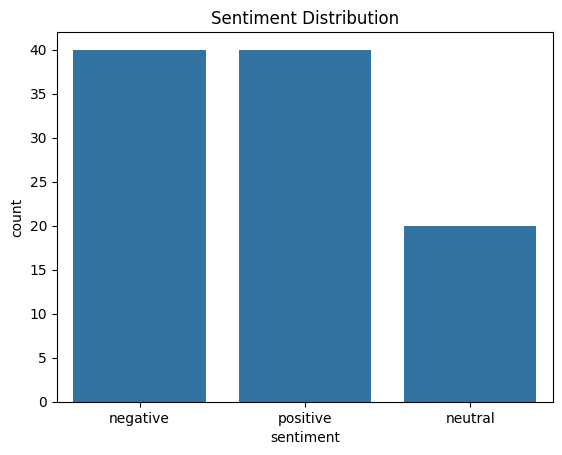

In [ ]:
sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")

plt.show()

In [ ]:
stemmer = PorterStemmer()

stop_words = set(stopwords.words('english'))

def clean_text(text):

    # Remove special characters
    text = re.sub('[^a-zA-Z]', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Split words
    text = text.split()

    # Remove stopwords and apply stemming
    text = [stemmer.stem(word) for word in text if word not in stop_words]

    return ' '.join(text)

In [ ]:
df['clean_text'] = df['text'].apply(clean_text)

df.head()

,text,sentiment,clean_text
0,This app crashes frequently,negative,app crash frequent
1,The movie was boring,negative,movi bore
2,Excellent experience overall,positive,excel experi overal
3,Best purchase I have made,positive,best purchas made
4,I regret buying this,negative,regret buy


In [ ]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['clean_text'])

y = df['sentiment']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LogisticRegression()

model.fit(X_train, y_train)


LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.85


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.75      1.00      0.86         6
     neutral       1.00      0.50      0.67         2
    positive       0.91      0.83      0.87        12

    accuracy                           0.85        20
   macro avg       0.89      0.78      0.80        20
weighted avg       0.87      0.85      0.85        20



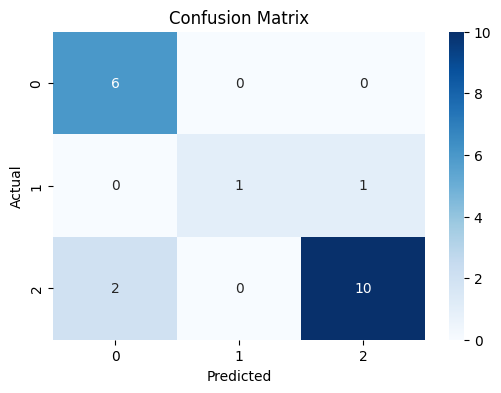

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
sample = "This product is amazing"

sample_clean = clean_text(sample)

sample_vector = vectorizer.transform([sample_clean])

prediction = model.predict(sample_vector)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: positive


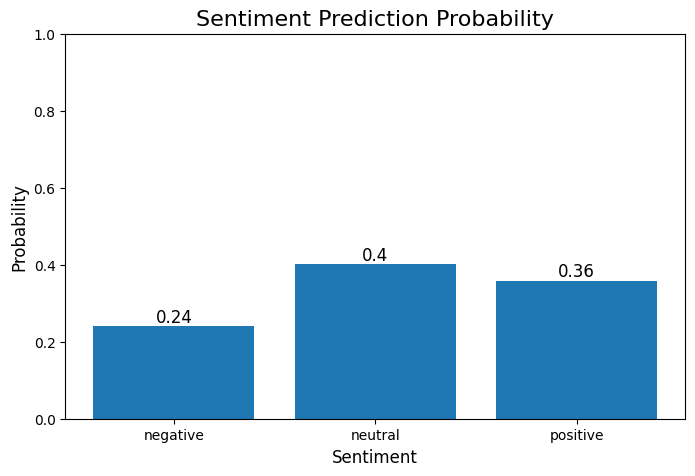

Text: This product is amazing and very useful
Predicted Sentiment: neutral


In [ ]:
# Custom Text Prediction Visualization

sample = "This product is amazing and very useful"

# Clean the text
sample_clean = clean_text(sample)

# Convert into vector
sample_vector = vectorizer.transform([sample_clean])

# Predict sentiment
prediction = model.predict(sample_vector)[0]

# Prediction probabilities
probabilities = model.predict_proba(sample_vector)[0]

# Labels
labels = model.classes_

# Create DataFrame
result_df = pd.DataFrame({
    'Sentiment': labels,
    'Probability': probabilities
})

# Plot
plt.figure(figsize=(8,5))

bars = plt.bar(result_df['Sentiment'],
               result_df['Probability'])

# Add values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 0.01,
             round(yval,2),
             ha='center',
             fontsize=12)

plt.title("Sentiment Prediction Probability",
          fontsize=16)

plt.xlabel("Sentiment",
           fontsize=12)

plt.ylabel("Probability",
           fontsize=12)

plt.ylim(0,1)

plt.show()

# Final Prediction
print("Text:", sample)
print("Predicted Sentiment:", prediction)
